# Modelos basados en árboles: Random Forest 

Este notebook recoge los dos modelos no lineales de la comparación. El objetivo es comprobar si capturar relaciones no lineales e interacciones entre variables mejora la estimación respecto a Ridge y baseline.

Un árbol de decisión divide las fases en grupos mediante preguntas sucesivas sobre las variables. Cada grupo final recibe como predicción el valor medio del ratio de las fases de entrenamiento que contiene.

Un único árbol es fácil de interpretar, pero es inestable: pequeños cambios en los datos producen árboles muy distintos. Por eso se utilizan combinaciones de muchos árboles.

### Random Forest
Random Forest (Breiman, 2001) entrena muchos árboles independientes. Cada árbol usa una muestra aleatoria de las fases y de las variables. La predicción final es la media de todos los árboles. Al promediar, se reduce la inestabilidad de un árbol individual.


### Por qué se valoran estos modelos en este problema
- **Relaciones no lineales.** El análisis de la variable objetivo mostró que el ratio disminuye con la duración de la fase, pero no de forma lineal: sube mucho en las fases cortas y se estabiliza en las largas. Los árboles captan este tipo de relación sin necesidad de transformar las variables.
- **Interacciones entre variables.** El efecto de una máquina puede depender del tipo de fase o de la duración. Ridge no modela estas interacciones salvo que se definan explícitamente. Los árboles las capturan de forma automática.
- **Variables categóricas con muchas categorías.** Las máquinas, los tipos de fase y las familias de producto se tratan de forma natural.
- **Sin necesidad de escalado.** Los árboles dividen por umbrales, así que la escala de las variables de entrada no afecta al resultado.

### Variable objetivo
Siguiendo el mismo diseño experimental que con Ridge, cada modelo se entrena con dos formulaciones: ratio y log(ratio). Las predicciones de log(ratio) se devuelven a escala ratio antes de calcular las métricas. Así se comprueba si la transformación aporta valor también en modelos no lineales, o si la mejora era propia del modelo lineal.

### Limitaciones
- Son menos interpretables que Ridge: no hay un coeficiente por variable. Su interpretación se abordará con importancia de variables y SHAP.
- Tienen más hiperparámetros que ajustar y mayor riesgo de sobreajuste. Se controlarán con la misma validación cruzada temporal (3 folds).

En Random Forest suele utilizarse una conversión ordinal en vez de OHE para las variables categóricas.

A simple vista, la conversión ordinal no es la más acertada, ya que las categorías no siguen ni presentan ningún orden. Sin embargo, el árbol no hace cálculos con ese número: simplemente lo usa para determinar los cortes entre categorías. De esta forma no es necesario crear una columna para cada categoría.

La idea es ahorrar columnas, pero se presenta un problema: un solo corte no puede agrupar categorías que no sean contiguas en la numeración. El árbol puede llegar a separarlas, pero necesita más cortes, lo que lo hace menos eficiente. Más adeltane LightGBM, con su tratamiento nativo de las variables categóricas, no tiene esta limitación, y la comparación entre ambos modelos permitirá valorar su efecto.

Puntos del notebook:
1. Cargar datos y definir variables
2. Preparar las variables para Random Forest (feature engineering)
3. Entrenar y validar Random Forest (rf) en los 3 folds
4. Entrenar y validar con los 3 folds (log(ratio)) en los 3 folds
5. Guardar predicciones y comparar con Baseline

In [13]:
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

from funciones_modelado import metricas, obtener_fold

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

## 1. Cargar datos y definir variables

In [ ]:
# Datos y folds
df = pd.read_parquet("datos/df_split.parquet")
folds = pd.read_csv("datos/folds.csv", dtype=str)

In [4]:
display(df.sample(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio,inicio_orden,mes_orden,split,maquina_no_vista
2637,2025-12-11 14:43:51.533,30b006e8-81a2-4579-af52-71d32a088033,OF2511964,CV-BAL,CM08,CV-ALU,B,BAL,1.0,60.0,0.596667,2025-12-11 14:43:51.533,2025-12,desarrollo,False


In [ ]:
MESES_VALIDACION = folds["mes_validacion"].tolist()

VARIABLES_CATEGORICAS = ["CodigoMaquina", "Familia Maquinas", "TipoFase", "Línea Producto", "Família Producto"]
VARIABLES_NUMERICAS   = ["TiempoPrevisto", "Quantity"]
OBJETIVO              = "ratio"

# Relleno de vacíos (igual que en Ridge) → OrdinalEncoder no acepta NaN
df["Línea Producto"]   = df["Línea Producto"].fillna("Desconocida")
df["Família Producto"] = df["Família Producto"].fillna("Desconocida")



## 2. Preparar las variables 

In [ ]:
preprocesado_rf = ColumnTransformer([
    ("categoricas",
     OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, # gestionar las categorias desconocidas
                    min_frequency=30), # agrupar categorias poco frecuentes
     VARIABLES_CATEGORICAS),
    ("numericas", 
     "passthrough", VARIABLES_NUMERICAS), # no tratar las variables numéricas
])

hoja = []

modelo_rf = Pipeline([
    ("preprocesado", preprocesado_rf),
    ("rf", RandomForestRegressor(n_estimators=300, min_samples_leaf=hoja, # min_samples_leaf suele ser el hiperparametros que más influye 
                                 n_jobs=-1, random_state=42)),
])

Procedo a averiguar la mejor combinación para el modelo:         

`n_estimators`=300 habitualmente da los mejores resultados así que no experimentare con otras combinaciones.       

`min_samples_leaf` es el hiperparámetro más influyente, así que probare disitntas configuraciones. 

## 3. Entrenar y validar Random Forest (rf) en los 3 folds

In [12]:
HOJAS = [1, 5, 10, 20, 30, 40, 50]

filas = []
for hoja in HOJAS:
    modelo_rf.set_params(rf__min_samples_leaf=hoja)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_rf.fit(train, train[OBJETIVO])                    # APRENDER
        pred = modelo_rf.predict(valid)                          # PREDECIR

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        maes_train.append(metricas(train[OBJETIVO], modelo_rf.predict(train))["MAE"])

    filas.append({"número_hojas": hoja,
                  "MAE_train":  np.mean(maes_train),
                  "MAE_medio_val":  np.mean(maes), # el de los 3 folds
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_rf = pd.DataFrame(filas).round(3)
print(ajuste_rf)

   número_hojas  MAE_train  MAE_medio_val  RMSE_medio           MAE_por_fold
0             1      0.715          0.882       1.269  [0.931, 0.846, 0.869]
1             5      0.792          0.862       1.244  [0.917, 0.835, 0.833]
2            10      0.816          0.860       1.240  [0.918, 0.834, 0.827]
3            20      0.835          0.860       1.239  [0.921, 0.833, 0.826]
4            30      0.845          0.863       1.241  [0.924, 0.838, 0.828]
5            40      0.850          0.864       1.242   [0.924, 0.838, 0.83]
6            50      0.855          0.866       1.243   [0.925, 0.84, 0.832]


Lo interesante es encontrar la mínima diferencia entre MAE en train y en Validacion.   

El hiperparámetro ajustado es `min_samples_leaf`: el número mínimo de fases que debe tener cada hoja del árbol. Se han probado los valores 1, 5, 10, 20, 30, 40 y 50 con los mismos 3 folds temporales. El criterio de elección es el menor MAE medio en validación. Además, se ha calculado el MAE sobre el propio entrenamiento para diagnosticar el sobreajuste.

El error en validación tiene forma de U. Baja al pasar de 1 a 10–20 y vuelve a subir en 50. El mínimo (0,860) se alcanza en 10 y en 20.

Con hojas de una sola fase se produce sobreajuste. Es el valor con menor error en entrenamiento y mayor error en validación: el modelo memoriza los datos de entrenamiento y generaliza peor. A medida que las hojas crecen, el error en entrenamiento aumenta y la diferencia con validación se reduce. Con 50 fases por hoja la diferencia es mínima, pero el error en validación vuelve a subir: el modelo empieza a perder detalle.

Febrero es el fold con más error para todos los valores probados, igual que en Ridge.

La diferencia entre 10 y 20 es mínima, puede ser interesantes inspeccionar el intervalo entre 20 y 50 para encontrar un vaSe adopta **min_samples_leaf = 20**. Empata con 10 en MAE medio, pero presenta un RMSE ligeramente menor y una diferencia menor entre entrenamiento y validación. Es decir, generaliza de forma más consistente.

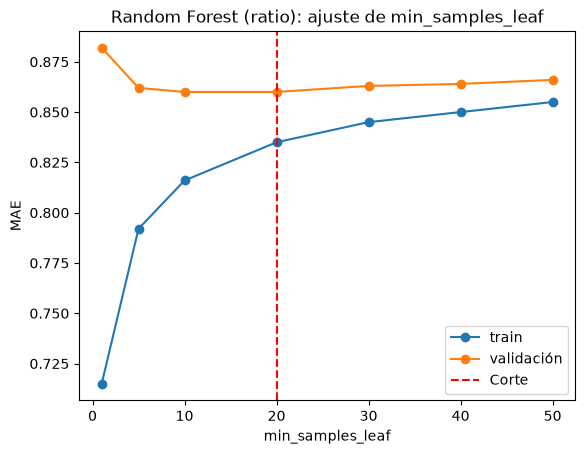

In [20]:
plt.plot(ajuste_rf["número_hojas"], ajuste_rf["MAE_train"], marker="o", label="train")
plt.plot(ajuste_rf["número_hojas"], ajuste_rf["MAE_medio_val"], marker="o", label="validación")
plt.xlabel("min_samples_leaf")
plt.ylabel("MAE")
plt.title("Random Forest (ratio): ajuste de min_samples_leaf")
plt.axvline(x=20, color="red", linestyle="--", linewidth=1.5, label="Corte")
plt.legend()
plt.show()

Lo interesante aquí es la recta de validación. 

La curva de validación baja claramente entre 1 y 5 (0,882 → 0,862) y a partir de ahí se mantiene casi plana, con el mínimo en 10–20 (0,860). La curva de entrenamiento sube con fuerza hasta 10 y después de forma más suave. Las dos curvas se acercan a medida que crecen las hojas.

Con hojas de una sola fase el modelo memoriza el entrenamiento, pero generaliza peor. Casi todo el efecto del hiperparámetro está en evitar ese caso: a partir de 5, el valor exacto apenas cambia el error en validación (menos de 5 milésimas). El modelo es robusto a la elección de min_samples_leaf.

### 4. Entrenar y validar con los 3 folds (log(ratio))

In [16]:
HOJAS = [1, 5, 10, 20, 30, 40, 50]

filas = []
for hoja in HOJAS:
    modelo_rf.set_params(rf__min_samples_leaf=hoja)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_rf.fit(train, np.log(train[OBJETIVO]))                 # ← APRENDER con log(ratio)
        pred = np.exp(modelo_rf.predict(valid))                       # ← PREDECIR y volver a escala ratio

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        pred_train = np.exp(modelo_rf.predict(train))                 # ← train también en escala ratio
        maes_train.append(metricas(train[OBJETIVO], pred_train)["MAE"])

    filas.append({"número_hojas": hoja,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_rf_log = pd.DataFrame(filas).round(3)
print(ajuste_rf_log)

   número_hojas  MAE_train  MAE_medio_val  RMSE_medio           MAE_por_fold
0             1      0.687          0.868       1.323   [0.925, 0.828, 0.85]
1             5      0.759          0.847       1.310   [0.91, 0.814, 0.818]
2            10      0.781          0.846       1.308   [0.91, 0.816, 0.812]
3            20      0.798          0.845       1.308  [0.911, 0.815, 0.809]
4            30      0.807          0.846       1.311  [0.912, 0.819, 0.807]
5            40      0.812          0.848       1.312  [0.914, 0.821, 0.809]
6            50      0.816          0.850       1.314  [0.916, 0.822, 0.811]


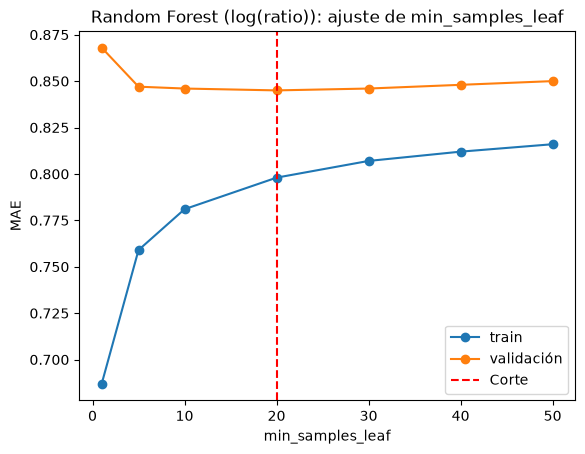

In [19]:
plt.plot(ajuste_rf_log["número_hojas"], ajuste_rf_log["MAE_train"], marker="o", label="train")
plt.plot(ajuste_rf_log["número_hojas"], ajuste_rf_log["MAE_medio_val"], marker="o", label="validación")
plt.xlabel("min_samples_leaf")
plt.ylabel("MAE")
plt.title("Random Forest (log(ratio)): ajuste de min_samples_leaf")
plt.axvline(x=20, color="red", linestyle="--", linewidth=1.5, label="Corte")
plt.legend()
plt.show()

Se repite el mismo patrón que en la versión ratio. El error en validación baja claramente entre 1 y 5 y a partir de ahí se mantiene casi plano. El mínimo está en 20 (0,845), que también empata en el menor RMSE (1,308).

Con hojas de una sola fase hay sobreajuste: el menor error en entrenamiento (0,687) y el mayor en validación. La diferencia entre entrenamiento y validación se reduce a medida que crecen las hojas. Febrero sigue siendo el fold con más error.

Se adopta **min_samples_leaf = 20**, el mismo valor que en la versión ratio. Así, la única diferencia entre ambas formulaciones es la variable objetivo.

### 5. Guardar predicciones y comparar con Baseline

In [21]:
modelo_rf.set_params(rf__min_samples_leaf=20)

filas_ratio, filas_log, partes = [], [], []
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df, mes)

    # Versión ratio
    modelo_rf.fit(train, train[OBJETIVO])
    pred_ratio = modelo_rf.predict(valid)

    # Versión log(ratio)
    modelo_rf.fit(train, np.log(train[OBJETIVO]))
    pred_log = np.exp(modelo_rf.predict(valid))

    # Métricas por fold
    filas_ratio.append({"bloque": f"valid {mes}", "n_train": len(train),
                        **metricas(valid[OBJETIVO], pred_ratio)})
    filas_log.append({"bloque": f"valid {mes}", "n_train": len(train),
                      **metricas(valid[OBJETIVO], pred_log)})

    # Predicciones fase a fase
    partes.append(pd.DataFrame({
        "IDMOTask":      valid["IDMOTask"].values,
        "mes_orden":     valid["mes_orden"].values,
        "ratio":         valid[OBJETIVO].values,
        "pred_rf_ratio": pred_ratio,
        "pred_rf_log":   pred_log,
    }))

resultados_rf     = pd.DataFrame(filas_ratio).round(3)
resultados_rf_log = pd.DataFrame(filas_log).round(3)
pred_rf_valid     = pd.concat(partes, ignore_index=True)

print("RF ratio\n", resultados_rf)
print("\nRF log(ratio)\n", resultados_rf_log)

RF ratio
           bloque  n_train    MAE   RMSE    n
0  valid 2026-02     8940  0.921  1.312  919
1  valid 2026-03     9859  0.833  1.209  997
2  valid 2026-04    10856  0.826  1.196  971

RF log(ratio)
           bloque  n_train    MAE   RMSE    n
0  valid 2026-02     8940  0.911  1.386  919
1  valid 2026-03     9859  0.815  1.272  997
2  valid 2026-04    10856  0.809  1.267  971


Con min_samples_leaf = 20 en ambas versiones, log(ratio) obtiene menor MAE en los 3 folds (0,845 de media frente a 0,860). La ventaja es pequeña, pero consistente. En RMSE ocurre lo contrario: la versión ratio es mejor en los 3 folds (1,239 frente a 1,308).

Las dos métricas no coinciden, igual que en Ridge. La versión log reduce el error en la fase típica, pero comete más error en las fases con desviaciones grandes.

Como el MAE es la métrica principal, se considera log(ratio) la mejor versión de Random Forest. La transformación logarítmica mantiene su ventaja también en un modelo no lineal.

In [22]:
pred_rf_valid.to_parquet("predicciones/rf_valid.parquet", index=False)